# Pensjonsdemografi og pensjonsvolum

Denne notebooken analyserer ferdige **Gold-data** fra Pensjon Lakehouse-pipelinen.

Rapporten bruker bare filer fra:

```text
/tmp/pensjon_lakehouse/gold/
```

Den leser altså ikke direkte fra Bronze- eller Silver-laget.

Rapporten viser:

1. Utvikling i gjennomsnittlig pensjonsandel 55+ over tid
2. Kommuner med høyest andel innbyggere 55+
3. Aldersgruppefordeling for nyeste år
4. Empirisk aldersfordelingskurve for nyeste år
5. Endring i aldersgrupper fra første til siste år
6. Seniorer 55+ relativt til personer i alderen 20–54
7. Næringer med høyest estimert pensjonsvolum
8. Sammenheng mellom antall lønnstakere og månedslønn per næring

Forutsetning:

```bash
python main.py
```

må være kjørt først, slik at Gold-dataene finnes.

## 1. Imports og paths

Notebooken leser ferdige Parquet-filer fra Gold-laget. Den henter ikke data fra SSB og kjører ikke selve lakehouse-pipelinen på nytt.

In [1]:
from pathlib import Path
import sys

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
LAKE = Path("/tmp/pensjon_lakehouse")
GOLD = LAKE / "gold"
REPORTS = LAKE / "reports"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 2. Sjekk at nødvendige Gold-data finnes

Hvis denne cellen feiler, kjør `python main.py` fra prosjektroten først.

Denne notebooken forventer at Gold-laget inneholder både de opprinnelige Gold-filene og den nye ettårsaldersfordelingen.

In [4]:
required_files = [
    GOLD / "pensjonsandel_trend.parquet",
    GOLD / "top_kommuner_pensjonsalder.parquet",
    GOLD / "naering_pensjonsvolum.parquet",
    GOLD / "aldersgruppe_fordeling_siste_ar.parquet",
    GOLD / "aldersgruppe_trend.parquet",
    GOLD / "aldersfordeling_siste_ar.parquet",
]

missing_files = [file for file in required_files if not file.exists()]

if missing_files:
    raise FileNotFoundError(
        "Mangler Gold-filer. Kjør `python main.py` først, "
        "og sjekk at GoldStage bygger alle rapportfilene.\n"
        + "\n".join(str(file) for file in missing_files)
    )

for file in required_files:
    print(file)

/tmp/pensjon_lakehouse/gold/pensjonsandel_trend.parquet
/tmp/pensjon_lakehouse/gold/top_kommuner_pensjonsalder.parquet
/tmp/pensjon_lakehouse/gold/naering_pensjonsvolum.parquet
/tmp/pensjon_lakehouse/gold/aldersgruppe_fordeling_siste_ar.parquet
/tmp/pensjon_lakehouse/gold/aldersgruppe_trend.parquet
/tmp/pensjon_lakehouse/gold/aldersfordeling_siste_ar.parquet


## 3. Koble til DuckDB

DuckDB brukes kun til å lese ferdige Gold-Parquet-filer.

In [5]:
db = duckdb.connect()

## 4. Pensjonsandel 55+ over tid

Denne figuren viser hvordan gjennomsnittlig andel innbyggere 55+ utvikler seg over tid.

In [6]:
df_trend = db.execute(f"""
    SELECT
        year,
        snitt_pensjonsandel_pst,
        total_55_pluss,
        total_befolkning
    FROM read_parquet('{GOLD}/pensjonsandel_trend.parquet')
    ORDER BY year
""").fetchdf()

df_trend

,year,snitt_pensjonsandel_pst,total_55_pluss,total_befolkning
0,2022,36.16,1647864.0,5425270.0
1,2023,36.47,1682839.0,5488984.0
2,2024,36.76,1721384.0,5550203.0
3,2025,37.22,1758689.0,5594340.0
4,2026,37.60,1792105.0,5627400.0


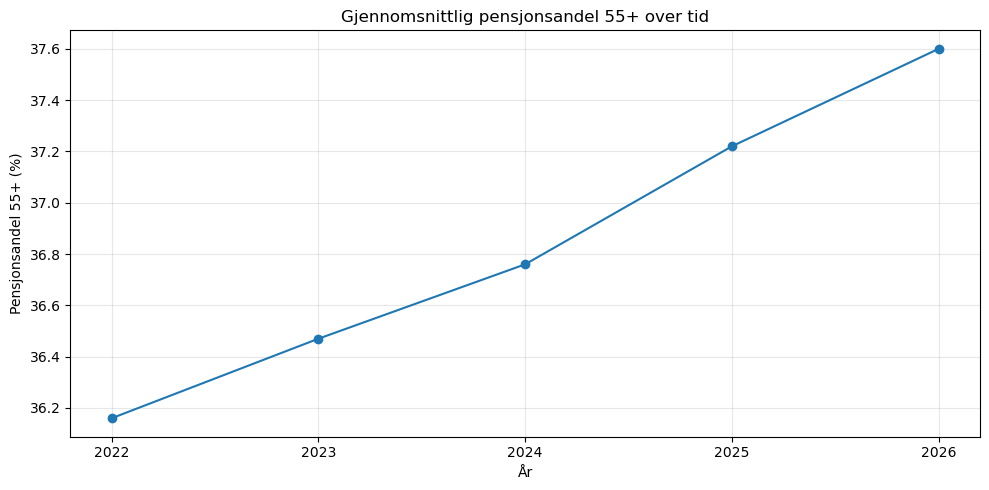

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_trend["year"],
    df_trend["snitt_pensjonsandel_pst"],
    marker="o",
)

plt.title("Gjennomsnittlig pensjonsandel 55+ over tid")
plt.xlabel("År")
plt.ylabel("Pensjonsandel 55+ (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Kommuner med høyest andel 55+

Her ser vi hvilke kommuner som har størst andel innbyggere i aldersgruppen 55+.

In [8]:
df_kommuner = db.execute(f"""
    WITH top10 AS (
        SELECT
            kommune_label,
            total_befolkning,
            pension_age_befolkning,
            CAST(ROUND(pension_age_share * 100, 1) AS DECIMAL(5, 1)) AS andel_55_pluss
        FROM read_parquet('{GOLD}/top_kommuner_pensjonsalder.parquet')
        ORDER BY pension_age_share DESC
        LIMIT 10
    )
    SELECT *
    FROM top10
    ORDER BY andel_55_pluss ASC
""").fetchdf()

df_kommuner

,kommune_label,total_befolkning,pension_age_befolkning,andel_55_pluss
0,Beiarn,1032.0,496.0,48.1
1,Bindal,1361.0,656.0,48.2
2,Stor-Elvdal,2239.0,1079.0,48.2
3,Grue,4463.0,2174.0,48.7
4,Engerdal,1287.0,628.0,48.8
5,Tydal,773.0,379.0,49.0
6,Rendalen,1836.0,906.0,49.3
7,Lødingen,1964.0,986.0,50.2
8,Ibestad,1287.0,654.0,50.8
9,Hvaler,4714.0,2412.0,51.2


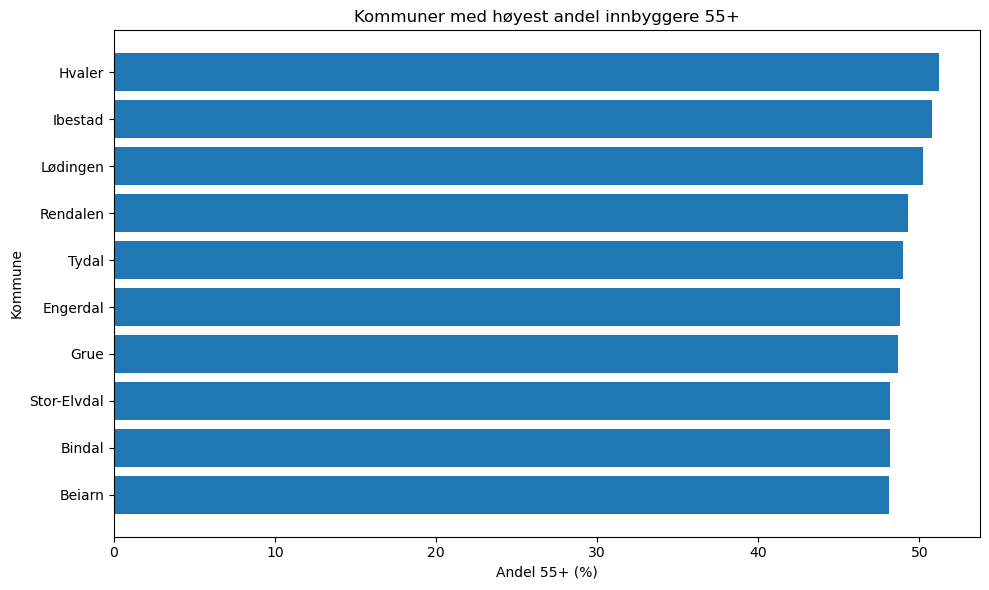

In [9]:
plt.figure(figsize=(10, 6))

plt.barh(
    df_kommuner["kommune_label"],
    df_kommuner["andel_55_pluss"],
)

plt.title("Kommuner med høyest andel innbyggere 55+")
plt.xlabel("Andel 55+ (%)")
plt.ylabel("Kommune")
plt.tight_layout()
plt.show()

## 6. Aldersgruppefordeling nyeste år

Dette er en grov aldersfordeling basert på rapportklare aldersgrupper i Gold-laget.

In [10]:
df_aldersfordeling = db.execute(f"""
    SELECT
        aldersgruppe,
        aldersgruppe_sortering,
        befolkning,
        CAST(ROUND(andel * 100, 1) AS DECIMAL(5, 1)) AS andel_prosent
    FROM read_parquet('{GOLD}/aldersgruppe_fordeling_siste_ar.parquet')
    ORDER BY aldersgruppe_sortering
""").fetchdf()

df_aldersfordeling

,aldersgruppe,aldersgruppe_sortering,befolkning,andel_prosent
0,0-19,1,1238634.0,22.0
1,20-34,2,1095524.0,19.5
2,35-49,3,1125961.0,20.0
3,50-54,4,375176.0,6.7
4,55-61,5,514638.0,9.2
5,62-66,6,317834.0,5.7
6,67-74,7,439782.0,7.8
7,75+,8,519851.0,9.2


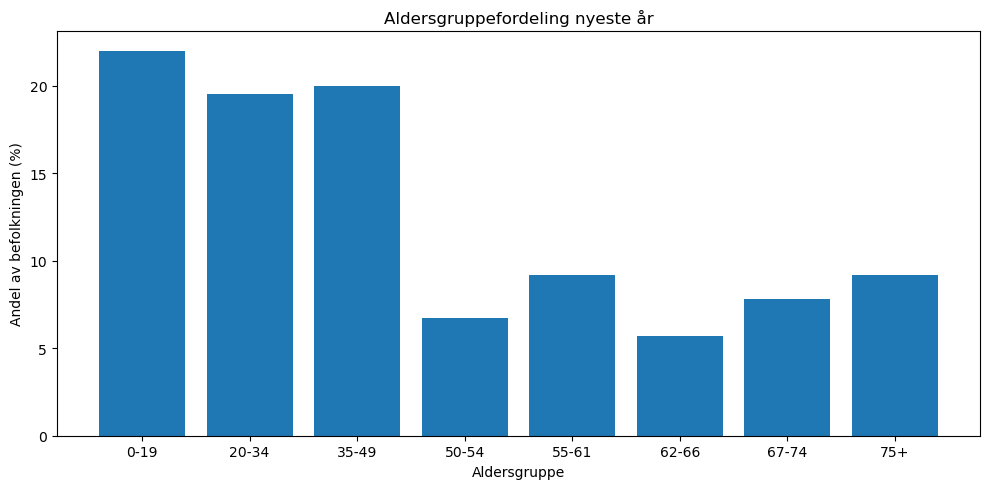

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(
    df_aldersfordeling["aldersgruppe"],
    df_aldersfordeling["andel_prosent"],
)

plt.title("Aldersgruppefordeling nyeste år")
plt.xlabel("Aldersgruppe")
plt.ylabel("Andel av befolkningen (%)")
plt.tight_layout()
plt.show()

## 7. Empirisk aldersfordelingskurve for nyeste år

Denne figuren bruker den rapportklare ettårsaldersfordelingen i Gold-laget:

```text
gold/aldersfordeling_siste_ar.parquet
```

Den svarer på spørsmålet:

> Hvordan ser befolkningens aldersprofil ut nå?

In [12]:
df_alder_siste_ar = db.execute(f"""
    SELECT
        year,
        alder,
        befolkning,
        andel * 100 AS andel_prosent
    FROM read_parquet('{GOLD}/aldersfordeling_siste_ar.parquet')
    ORDER BY alder
""").fetchdf()

df_alder_siste_ar["glattet_andel_prosent"] = (
    df_alder_siste_ar["andel_prosent"]
    .rolling(window=5, center=True, min_periods=1)
    .mean()
)

df_alder_siste_ar

,year,alder,befolkning,andel_prosent,glattet_andel_prosent
0,2026,0,55578.0,0.9876,0.969067
1,2026,1,54634.0,0.9709,0.965375
2,2026,2,53386.0,0.9487,0.980920
3,2026,3,53700.0,0.9543,0.982620
4,2026,4,58702.0,1.0431,0.993340
...,...,...,...,...,...
101,2026,101,362.0,0.0064,0.007180
102,2026,102,186.0,0.0033,0.004500
103,2026,103,101.0,0.0018,0.002900
104,2026,104,55.0,0.0010,0.002025


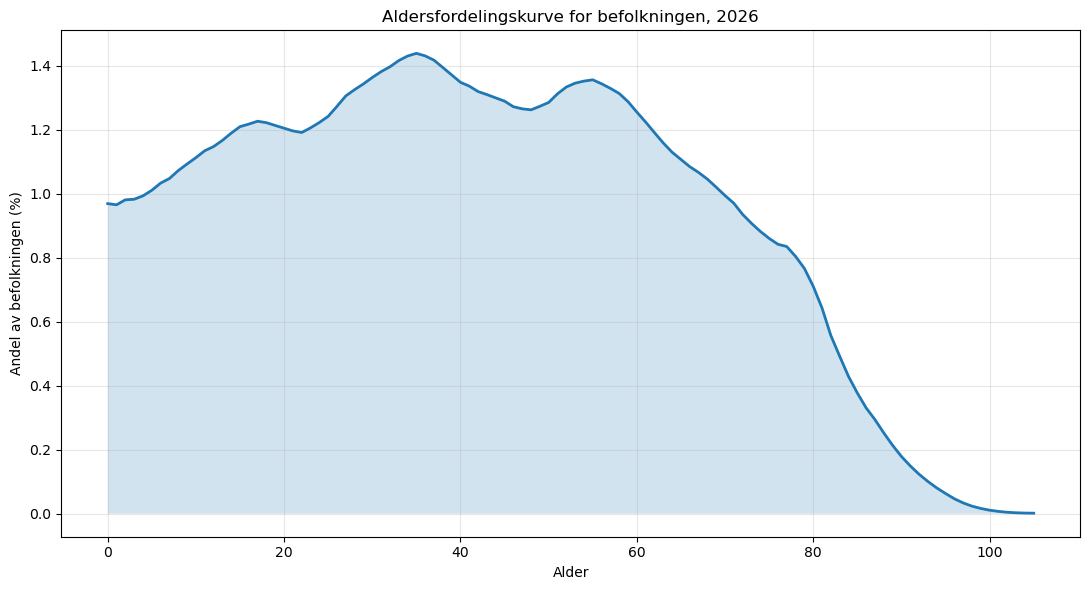

In [13]:
latest_year = int(df_alder_siste_ar["year"].iloc[0])

plt.figure(figsize=(11, 6))

plt.plot(
    df_alder_siste_ar["alder"],
    df_alder_siste_ar["glattet_andel_prosent"],
    linewidth=2,
)

plt.fill_between(
    df_alder_siste_ar["alder"],
    df_alder_siste_ar["glattet_andel_prosent"],
    alpha=0.2,
)

plt.title(f"Aldersfordelingskurve for befolkningen, {latest_year}")
plt.xlabel("Alder")
plt.ylabel("Andel av befolkningen (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Endring i aldersgrupper fra første til siste år

Denne figuren viser hvilke aldersgrupper som faktisk øker eller faller som andel av befolkningen.

Dette er mer informativt enn å plotte flere nesten like aldersfordelingskurver over tid.

In [14]:
df_aldersgruppe_trend_long = db.execute(f"""
    SELECT
        year,
        aldersgruppe,
        aldersgruppe_sortering,
        befolkning,
        CAST(ROUND(andel * 100, 1) AS DECIMAL(5, 1)) AS andel_prosent
    FROM read_parquet('{GOLD}/aldersgruppe_trend.parquet')
    ORDER BY year, aldersgruppe_sortering
""").fetchdf()

first_year = df_aldersgruppe_trend_long["year"].min()
last_year = df_aldersgruppe_trend_long["year"].max()

df_aldersgruppe_endring = (
    df_aldersgruppe_trend_long
    .pivot(
        index=["aldersgruppe", "aldersgruppe_sortering"],
        columns="year",
        values="andel_prosent",
    )
    .reset_index()
)

df_aldersgruppe_endring["endring_prosentpoeng"] = (
    df_aldersgruppe_endring[last_year] - df_aldersgruppe_endring[first_year]
)

df_aldersgruppe_endring = df_aldersgruppe_endring.sort_values("aldersgruppe_sortering")

df_aldersgruppe_endring

year,aldersgruppe,aldersgruppe_sortering,2022,2023,2024,2025,2026,endring_prosentpoeng
0,0-19,1,22.8,22.6,22.4,22.2,22.0,-0.8
1,20-34,2,20.1,20.0,19.9,19.7,19.5,-0.6
2,35-49,3,19.9,19.8,19.9,19.9,20.0,0.1
3,50-54,4,7.0,7.0,6.9,6.8,6.7,-0.3
4,55-61,5,8.7,8.8,8.9,9.1,9.2,0.5
5,62-66,6,5.6,5.6,5.6,5.6,5.7,0.1
6,67-74,7,7.8,7.7,7.7,7.8,7.8,0.0
7,75+,8,8.3,8.5,8.8,9.0,9.2,0.9


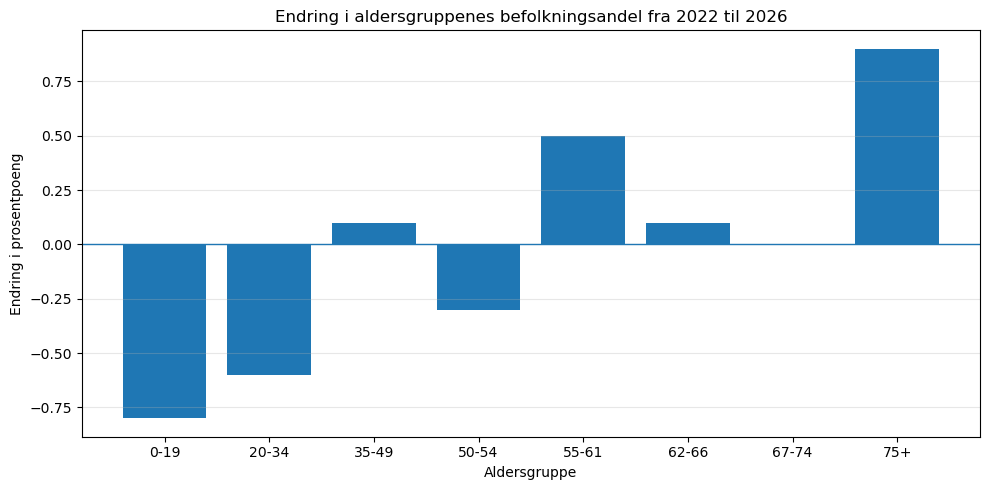

In [15]:
plt.figure(figsize=(10, 5))

plt.axhline(0, linewidth=1)

plt.bar(
    df_aldersgruppe_endring["aldersgruppe"],
    df_aldersgruppe_endring["endring_prosentpoeng"],
)

plt.title(f"Endring i aldersgruppenes befolkningsandel fra {first_year} til {last_year}")
plt.xlabel("Aldersgruppe")
plt.ylabel("Endring i prosentpoeng")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Seniorer relativt til yrkesaktiv alder

Denne figuren viser forholdet mellom:

- seniorer 55+
- personer i alderen 20–54

Dette gir en enkel indikator på demografisk pensjonspress.

In [16]:
df_seniorpress = db.execute(f"""
    SELECT
        year,
        SUM(
            CASE
                WHEN aldersgruppe IN ('20-34', '35-49', '50-54')
                THEN befolkning ELSE 0
            END
        ) AS yrkesaktiv_20_54,
        SUM(
            CASE
                WHEN aldersgruppe IN ('55-61', '62-66', '67-74', '75+')
                THEN befolkning ELSE 0
            END
        ) AS senior_55_pluss
    FROM read_parquet('{GOLD}/aldersgruppe_trend.parquet')
    GROUP BY year
    ORDER BY year
""").fetchdf()

df_seniorpress["senior_per_yrkesaktiv"] = (
    df_seniorpress["senior_55_pluss"]
    / df_seniorpress["yrkesaktiv_20_54"]
)

df_seniorpress

,year,yrkesaktiv_20_54,senior_55_pluss,senior_per_yrkesaktiv
0,2022,2542672.0,1647864.0,0.648084
1,2023,2564718.0,1682839.0,0.656150
2,2024,2584537.0,1721384.0,0.666032
3,2025,2592851.0,1758689.0,0.678284
4,2026,2596661.0,1792105.0,0.690157


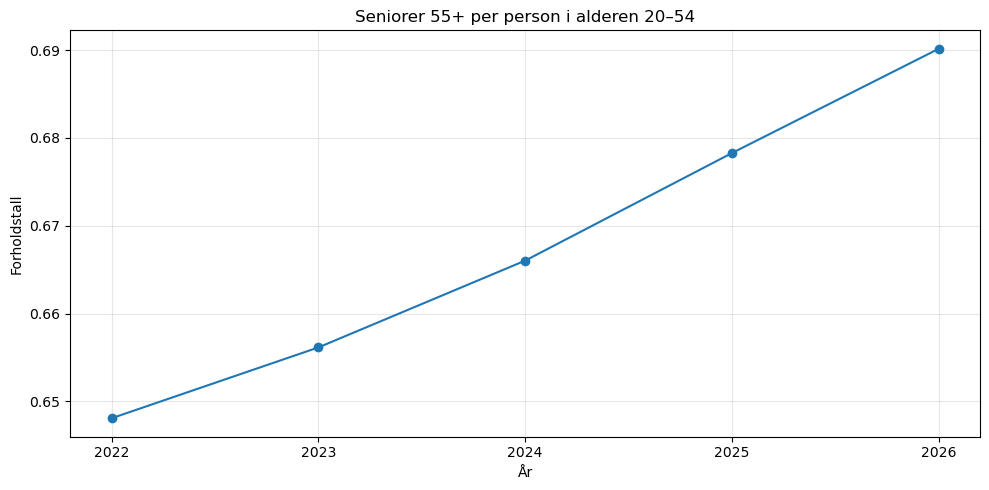

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_seniorpress["year"],
    df_seniorpress["senior_per_yrkesaktiv"],
    marker="o",
)

plt.title("Seniorer 55+ per person i alderen 20–54")
plt.xlabel("År")
plt.ylabel("Forholdstall")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Næringer med høyest estimert pensjonsvolum

Estimert pensjonsvolum er beregnet i pipelinen som:

```text
lønnstakere × månedslønn × 12 × 0.02
```

`Alle næringer` ekskluderes her fordi det er en totalsum, ikke en enkelt næring.

In [18]:
df_naering = db.execute(f"""
    WITH top10 AS (
        SELECT
            naering_label,
            lonsstakere,
            manedslonn,
            estimert_pensjonsvolum,
            estimert_pensjonsvolum / 1000000000 AS estimert_pensjonsvolum_mrd
        FROM read_parquet('{GOLD}/naering_pensjonsvolum.parquet')
        
        WHERE naering_label <> 'Alle næringer'
        ORDER BY estimert_pensjonsvolum DESC
        LIMIT 10
    )
    SELECT *
    FROM top10
    ORDER BY estimert_pensjonsvolum_mrd ASC
""").fetchdf()

df_naering

,naering_label,lonsstakere,manedslonn,estimert_pensjonsvolum,estimert_pensjonsvolum_mrd
0,Forretningsmessig tjenesteyting,139426,57220,1.914709e+09,1.914709
1,Transport og lagring,136108,61440,2.006994e+09,2.006994
2,Informasjon og kommunikasjon,112594,83440,2.254762e+09,2.254762
3,"Off.adm., forsvar, sosialforsikring",186074,67810,3.028243e+09,3.028243
4,Undervisning,229643,58690,3.234659e+09,3.234659
5,"Teknisk tjenesteyting, eiendomsdrift",182903,76780,3.370390e+09,3.370390
6,Industri,227217,63510,3.463332e+09,3.463332
7,Bygge- og anleggsvirksomhet,235240,61400,3.466497e+09,3.466497
8,"Varehandel, reparasjon av motorvogner",353894,57680,4.899025e+09,4.899025
9,Helse- og sosialtjenester,589694,56980,8.064183e+09,8.064183


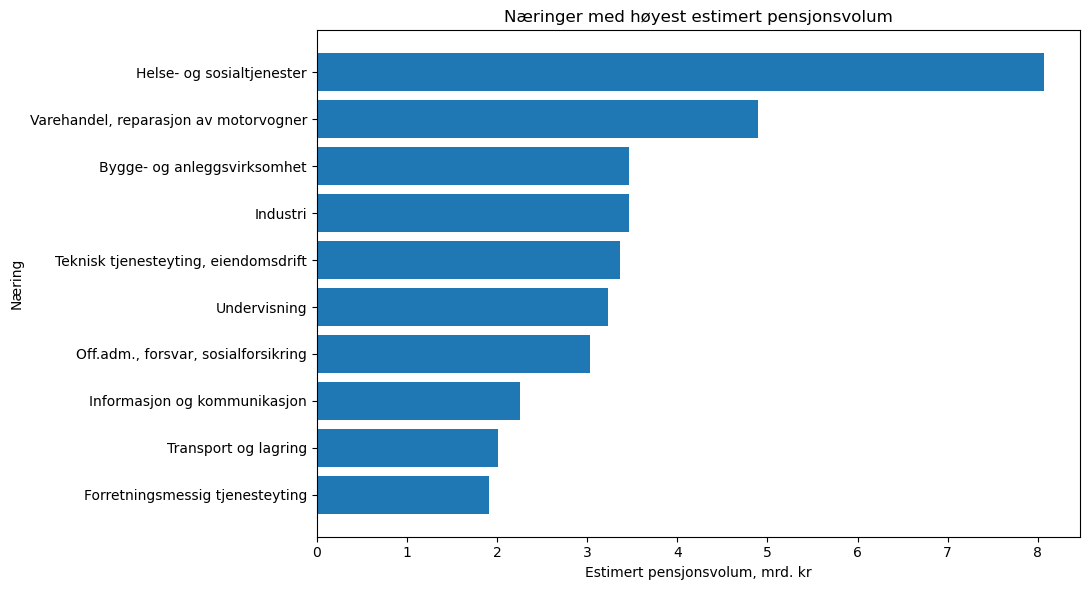

In [19]:
plt.figure(figsize=(11, 6))

plt.barh(
    df_naering["naering_label"],
    df_naering["estimert_pensjonsvolum_mrd"],
)

plt.title("Næringer med høyest estimert pensjonsvolum")
plt.xlabel("Estimert pensjonsvolum, mrd. kr")
plt.ylabel("Næring")
plt.tight_layout()
plt.show()

## 11. Lønnstakere og månedslønn per næring

Denne figuren gir et ekstra blikk på hva som driver pensjonsvolumet: mange ansatte, høy månedslønn, eller en kombinasjon.

In [20]:
df_naering_scatter = db.execute(f"""
    SELECT
        naering_label,
        lonsstakere,
        manedslonn,
        estimert_pensjonsvolum / 1000000000 AS estimert_pensjonsvolum_mrd
    
    FROM read_parquet('{GOLD}/naering_pensjonsvolum.parquet')
        WHERE naering_label <> 'Alle næringer'
    
    ORDER BY estimert_pensjonsvolum DESC
""").fetchdf()

df_naering_scatter

,naering_label,lonsstakere,manedslonn,estimert_pensjonsvolum_mrd
0,Helse- og sosialtjenester,589694,56980,8.064183
1,"Varehandel, reparasjon av motorvogner",353894,57680,4.899025
2,Bygge- og anleggsvirksomhet,235240,61400,3.466497
3,Industri,227217,63510,3.463332
4,"Teknisk tjenesteyting, eiendomsdrift",182903,76780,3.370390
5,Undervisning,229643,58690,3.234659
6,"Off.adm., forsvar, sosialforsikring",186074,67810,3.028243
7,Informasjon og kommunikasjon,112594,83440,2.254762
8,Transport og lagring,136108,61440,2.006994
9,Forretningsmessig tjenesteyting,139426,57220,1.914709


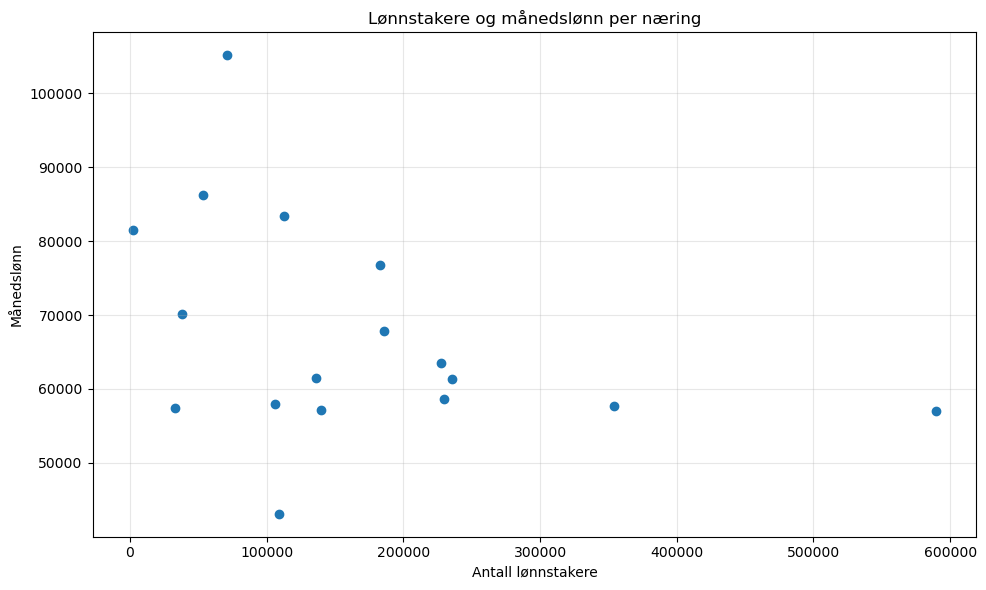

In [21]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_naering_scatter["lonsstakere"],
    df_naering_scatter["manedslonn"],
)

plt.title("Lønnstakere og månedslønn per næring")
plt.xlabel("Antall lønnstakere")
plt.ylabel("Månedslønn")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Kort oppsummering

Denne cellen trekker ut noen nøkkelpunkter fra analysen.

In [22]:
latest_year = df_trend["year"].max()

latest_share = df_trend.loc[
    df_trend["year"] == latest_year,
    "snitt_pensjonsandel_pst",
].iloc[0]

top_kommune = df_kommuner.sort_values(
    "andel_55_pluss",
    ascending=False,
).iloc[0]

top_naering = df_naering.sort_values(
    "estimert_pensjonsvolum_mrd",
    ascending=False,
).iloc[0]

largest_age_group = df_aldersfordeling.sort_values(
    "andel_prosent",
    ascending=False,
).iloc[0]

oldest_share = df_aldersfordeling.loc[
    df_aldersfordeling["aldersgruppe"] == "75+",
    "andel_prosent",
].iloc[0]

peak_age = df_alder_siste_ar.sort_values(
    "glattet_andel_prosent",
    ascending=False,
).iloc[0]

latest_seniorpress = df_seniorpress.loc[
    df_seniorpress["year"] == latest_year,
    "senior_per_yrkesaktiv",
].iloc[0]

print(f"Siste år i datasettet er {latest_year}.")
print(f"Gjennomsnittlig pensjonsandel 55+ er {latest_share:.1f} %.")
print(
    f"Kommunen med høyest andel 55+ er {top_kommune['kommune_label']} "
    f"med {float(top_kommune['andel_55_pluss']):.1f} %."
)
print(
    f"Største aldersgruppe siste år er {largest_age_group['aldersgruppe']} "
    f"med {float(largest_age_group['andel_prosent']):.1f} % av befolkningen."
)
print(
    f"Toppen i den glattede aldersfordelingen ligger rundt alder "
    f"{int(peak_age['alder'])}, med {peak_age['glattet_andel_prosent']:.2f} % av befolkningen."
)
print(f"Andelen 75+ siste år er {float(oldest_share):.1f} %.")
print(f"Seniorer 55+ per person i alderen 20–54 er {latest_seniorpress:.2f}.")
print(
    f"Næringen med høyest estimert pensjonsvolum er "
    f"{top_naering['naering_label']} "
    f"med ca. {top_naering['estimert_pensjonsvolum_mrd']:.1f} mrd. kr."
)

Siste år i datasettet er 2026.
Gjennomsnittlig pensjonsandel 55+ er 37.6 %.
Kommunen med høyest andel 55+ er Hvaler med 51.2 %.
Største aldersgruppe siste år er 0-19 med 22.0 % av befolkningen.
Toppen i den glattede aldersfordelingen ligger rundt alder 35, med 1.44 % av befolkningen.
Andelen 75+ siste år er 9.2 %.
Seniorer 55+ per person i alderen 20–54 er 0.69.
Næringen med høyest estimert pensjonsvolum er Helse- og sosialtjenester med ca. 8.1 mrd. kr.


## 13. Valgfritt: lagre grafene som PNG

Denne cellen lagrer de viktigste grafene til:

```text
/tmp/pensjon_lakehouse/reports/
```

In [23]:
REPORTS.mkdir(parents=True, exist_ok=True)

# Pensjonsandel over tid
plt.figure(figsize=(10, 5))
plt.plot(df_trend["year"], df_trend["snitt_pensjonsandel_pst"], marker="o")
plt.title("Gjennomsnittlig pensjonsandel 55+ over tid")
plt.xlabel("År")
plt.ylabel("Pensjonsandel 55+ (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / "pensjonsandel_55_pluss_trend.png", dpi=150)
plt.close()

# Kommuner med høyest andel 55+
plt.figure(figsize=(10, 6))
plt.barh(df_kommuner["kommune_label"], df_kommuner["andel_55_pluss"])
plt.title("Kommuner med høyest andel innbyggere 55+")
plt.xlabel("Andel 55+ (%)")
plt.ylabel("Kommune")
plt.tight_layout()
plt.savefig(REPORTS / "kommuner_hoyest_andel_55_pluss.png", dpi=150)
plt.close()

# Aldersgruppefordeling nyeste år
plt.figure(figsize=(10, 5))
plt.bar(df_aldersfordeling["aldersgruppe"], df_aldersfordeling["andel_prosent"])
plt.title("Aldersgruppefordeling nyeste år")
plt.xlabel("Aldersgruppe")
plt.ylabel("Andel av befolkningen (%)")
plt.tight_layout()
plt.savefig(REPORTS / "aldersgruppefordeling_nyeste_ar.png", dpi=150)
plt.close()

# Empirisk aldersfordelingskurve nyeste år
plt.figure(figsize=(11, 6))
plt.plot(df_alder_siste_ar["alder"], df_alder_siste_ar["glattet_andel_prosent"], linewidth=2)
plt.fill_between(df_alder_siste_ar["alder"], df_alder_siste_ar["glattet_andel_prosent"], alpha=0.2)
plt.title(f"Aldersfordelingskurve for befolkningen, {latest_year}")
plt.xlabel("Alder")
plt.ylabel("Andel av befolkningen (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / "aldersfordelingskurve_nyeste_ar.png", dpi=150)
plt.close()

# Endring i aldersgrupper
plt.figure(figsize=(10, 5))
plt.axhline(0, linewidth=1)
plt.bar(
    df_aldersgruppe_endring["aldersgruppe"],
    df_aldersgruppe_endring["endring_prosentpoeng"],
)
plt.title(f"Endring i aldersgruppenes befolkningsandel fra {first_year} til {last_year}")
plt.xlabel("Aldersgruppe")
plt.ylabel("Endring i prosentpoeng")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / "endring_aldersgrupper.png", dpi=150)
plt.close()

# Seniorer relativt til yrkesaktiv alder
plt.figure(figsize=(10, 5))
plt.plot(df_seniorpress["year"], df_seniorpress["senior_per_yrkesaktiv"], marker="o")
plt.title("Seniorer 55+ per person i alderen 20–54")
plt.xlabel("År")
plt.ylabel("Forholdstall")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / "seniorer_per_yrkesaktiv.png", dpi=150)
plt.close()

# Næringer med høyest estimert pensjonsvolum
plt.figure(figsize=(11, 6))
plt.barh(df_naering["naering_label"], df_naering["estimert_pensjonsvolum_mrd"])
plt.title("Næringer med høyest estimert pensjonsvolum")
plt.xlabel("Estimert pensjonsvolum, mrd. kr")
plt.ylabel("Næring")
plt.tight_layout()
plt.savefig(REPORTS / "naeringer_hoyest_estimert_pensjonsvolum.png", dpi=150)
plt.close()

print(f"Grafer lagret i: {REPORTS}")

Grafer lagret i: /tmp/pensjon_lakehouse/reports


## 14. Lukk DuckDB-forbindelsen

In [24]:
db.close()